For discrete variable:
$$ D_{KL}(p || q) = \sum_{i}p(x_i)(logp(x_i) - logq(x_i)) = \sum_{i}p(x_i)(log\frac{p(x_i)}{q(x_i)})$$

For continuous variable:
$$ D_{KL}(p || q) = \int p(x)(logp(x) - logq(x)) dx = \int p(x)(log\frac{p(x)}{q(x)}) dx $$
$$ D_{KL}(q || p) = \int q(x)(logq(x) - logp(x)) dx = \int q(x)(log\frac{q(x)}{p(x)}) dx $$



## Calculation of KL Divergence

In [ ]:
# define distributions
events = ['red', 'green', 'blue']
p = [0.10, 0.40, 0.50]
q = [0.80, 0.15, 0.05]

In [ ]:
# plot of distributions
from matplotlib import pyplot
# define distributions
events = ['red', 'green', 'blue']
p = [0.10, 0.40, 0.50]
q = [0.80, 0.15, 0.05]
print('P=%.3f Q=%.3f' % (sum(p), sum(q)))
# plot first distribution
pyplot.subplot(2,1,1)
pyplot.bar(events, p)
# plot second distribution
pyplot.subplot(2,1,2)
pyplot.bar(events, q)
# show the plot
pyplot.show()

In [ ]:
# calculate the kl divergence
def kl_divergence(p, q):
 return

In [ ]:
# calculate (P || Q)
kl_pq = kl_divergence(p, q)
print('KL(P || Q): %.3f bits' % kl_pq)
# calculate (Q || P)
kl_qp = kl_divergence(q, p)
print('KL(Q || P): %.3f bits' % kl_qp)

## Minimizing KL-divergence between two distributions

In [1]:
## Set up the libraries
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

try:
    import distrax
except:
    %pip install -qq distrax
    import distrax
try:
    import optax
except:
    %pip install -qq optax
    import optax
try:
    import seaborn as sns
except:
    %pip install -qq seaborn
    import seaborn as sns

from jax.config import config
config.update("jax_enable_x64", True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 kB 4.9 MB/s eta 0:00:00


<ipython-input-1-6a474fbc5852>:22: DeprecationWarning: Accessing jax.config via the jax.config submodule is deprecated.
  from jax.config import config


In [2]:
# Generate a bimodal distribution p

mix = 0.5 # mixing cofficient
mean_one, mean_two = 1, 10 # mean
scale_one, scale_two = 1, 1.5 # std
ptrue = distrax.MixtureSameFamily(
    mixture_distribution=distrax.Categorical(probs=[mix, 1 - mix]),
    components_distribution=distrax.Normal(loc=[mean_one, mean_two], scale=[scale_one, scale_two]),
)

In [3]:
key = jax.random.PRNGKey(1234)


def kl_sampling_inverse(params, p, samples=100000):  # loss function when KL(q:p)
    q = distrax.Normal(loc=params[0], scale=params[1]) # params[0] denotes the mean and params[1] is for the std.
    sample_set = q.sample(seed=key, sample_shape=samples) #sampling from q
    return jnp.mean(q.log_prob(sample_set) - p.log_prob(sample_set))


def kl_sampling(params, p, samples=100000):  # loss function when KL(p:q)
    q = distrax.Normal(loc=params[0], scale=params[1]) # params[0] denotes the mean and params[1] is for the std.
    sample_set = p.sample(seed=key, sample_shape=samples) #sampling from p
    return jnp.mean(p.log_prob(sample_set) - q.log_prob(sample_set))

In [4]:
def fit(params, optimizer, loss_fun, n_itr):
    opt_state = optimizer.init(params) #initialization
    loss = []
    fn = jax.jit(jax.value_and_grad(loss_fun))
    for i in range(n_itr):
        samples = 100000
         # Compute the loss and its gradients
        loss_value, grads = jax.value_and_grad(loss_fun)(params, ptrue, samples)
        # loss_value, grads = fn(params, ptrue, samples)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        loss.append(loss_value)
    return params, loss

In [5]:
optimizer = optax.adam(learning_rate=0.05)
n_itr = 400 # number of iterations
params_one = jnp.array([5.0, 8.0]) # Parameters for q
optimized_params_one, loss_one = fit(params=params_one, optimizer=optimizer, loss_fun=kl_sampling, n_itr=n_itr) #forward kl as training objective
params_two = jnp.array([5.0, 8.0]) # Parameters for q
optimized_params_two, loss_two = fit(params=params_two, optimizer=optimizer, loss_fun=kl_sampling_inverse, n_itr=n_itr) #reverse kl as training objective

Text(0.5, 1.0, 'Iteration vs loss\n$\\min_{p}\\ KL[q ; p]$')

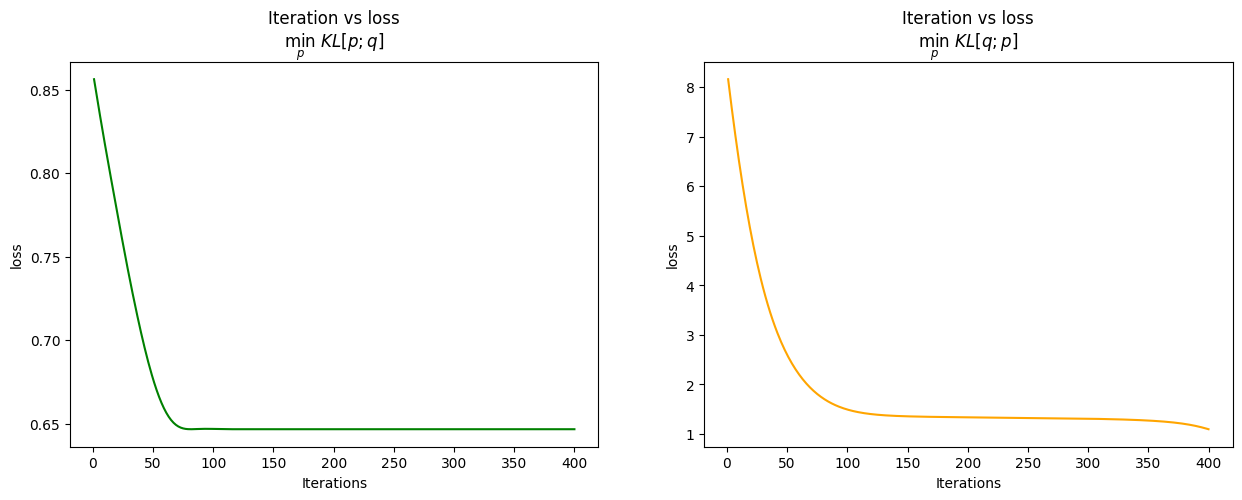

In [6]:
# Plot the loss curve
x_loss = jnp.linspace(1, n_itr, n_itr)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(x_loss, loss_one, color="green")
ax2.plot(x_loss, loss_two, color="orange")
ax1.set_xlabel("Iterations")
ax1.set_ylabel("loss")
ax1.set_title("Iteration vs loss\n" + r"$\min_{p}\ KL[p ; q]$")
ax2.set_xlabel("Iterations")
ax2.set_ylabel("loss")
ax2.set_title("Iteration vs loss\n" + r"$\min_{p}\ KL[q ; p]$")

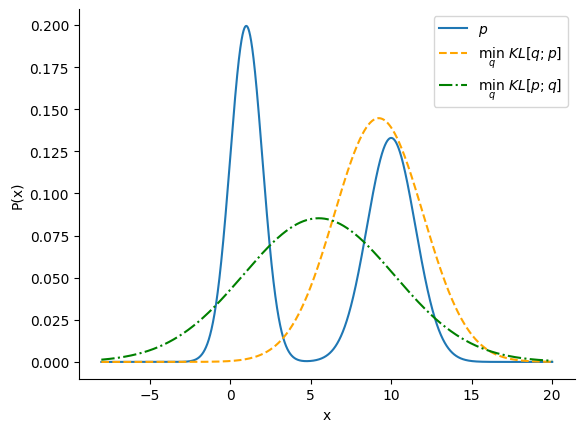

In [7]:
fig, ax = plt.subplots(1, 1)
x = jnp.linspace(-8, 20, int(1e6))
label_one = str()
label_two = str()
label_one = r"$\min_q\ KL[p ; q]$"
label_two = r"$\min_q\ KL[q ; p]$"
ax.plot(x, ptrue.prob(x), label=r"$p$") # plot the target distribution
ax.plot(
    x,
    distrax.Normal(loc=optimized_params_two[0], scale=optimized_params_two[1]).prob(x),
    color="orange",
    label=label_two,
    linestyle="--", # plot reverse KL
)
ax.plot(
    x,
    distrax.Normal(loc=optimized_params_one[0], scale=optimized_params_one[1]).prob(x),
    color="green",
    label=label_one, # plot forward KL
    linestyle="-.",
)
ax.set_xlabel("x")
ax.set_ylabel("P(x)")
ax.legend(fontsize=10, loc="upper right")
sns.despine()